# Task A — Exploration

Goal of this notebook:

1. Load the four downloaded files (metadata, dysbiosis scores, taxonomic profiles, pathway abundances).
2. Join them on sample ID into one tidy dataset.
3. Sanity-check sample counts and label distributions.
4. Make PCA and UMAP plots coloured by diagnosis and dysbiosis state.

This is **not** a model. It's the "I can read the data" gate before any ML.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path(".")
META_PATH = DATA_DIR / "hmp2_metadata.csv"
DYS_PATH = DATA_DIR / "dysbiosis_scores.tsv"
TAX_PATH = DATA_DIR / "taxonomic_profiles.tsv.gz"
PATH_PATH = DATA_DIR / "pathabundance_relab.tsv.gz"

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.max_columns = 50

## 1. Metadata

The metadata has one row per `(sample, data_type)` pair. We only want **metagenomics** (`MGX`) rows since the feature matrices we'll use (taxonomic profiles, pathway abundance) come from MGX.

In [3]:
meta_full = pd.read_csv(META_PATH, low_memory=False)
print(f"all rows: {len(meta_full):,}  cols: {meta_full.shape[1]}")
print("data_type breakdown:")
print(meta_full["data_type"].value_counts())

all rows: 5,533  cols: 490
data_type breakdown:
data_type
metagenomics            1638
metatranscriptomics      835
viromics                 703
metabolomics             546
proteomics               450
methylome                449
host_transcriptomics     252
serology                 210
stool_16S                180
biopsy_16S               178
host_genome               92
Name: count, dtype: int64


In [4]:
KEEP_COLS = [
    "External ID",
    "Participant ID",
    "site_sub_coll",
    "data_type",
    "week_num",
    "visit_num",
    "diagnosis",
    "Antibiotics",
    "consent_age",
    "sex",
    "race",
]
meta = (
    meta_full.loc[meta_full["data_type"] == "metagenomics", KEEP_COLS]
    .rename(columns={"External ID": "sample_id", "Participant ID": "participant_id"})
    .reset_index(drop=True)
)
print(f"MGX-only rows: {len(meta):,}")
print("\ndiagnosis breakdown (samples):")
print(meta["diagnosis"].value_counts(dropna=False))
print(f"\nunique participants: {meta['participant_id'].nunique()}")
meta.head()

MGX-only rows: 1,638

diagnosis breakdown (samples):
diagnosis
CD        750
UC        459
nonIBD    429
Name: count, dtype: int64

unique participants: 130


,sample_id,participant_id,site_sub_coll,data_type,week_num,visit_num,diagnosis,Antibiotics,consent_age,sex,race
0,CSM5FZ3N_P,C3001,C3001C1,metagenomics,0.0,4,CD,No,43.0,Female,White
1,CSM5FZ3R_P,C3001,C3001C2,metagenomics,2.0,5,CD,No,43.0,Female,White
2,CSM5YRY7_P,C3001,C3001C3,metagenomics,4.0,6,CD,No,43.0,Female,White
3,CSM5FZ3V_P,C3001,C3001C4,metagenomics,6.0,7,CD,No,43.0,Female,White
4,CSM5FZ4C_P,C3001,C3001C5,metagenomics,8.0,8,CD,No,43.0,Female,White


## 2. Dysbiosis scores

The dysbiosis score is the supervised label used in the Zhang 2022 paper. The TSV has no header and three columns: `sample_id`, `score`, `is_dysbiotic`.

In [5]:
dys = pd.read_csv(
    DYS_PATH,
    sep="\t",
    header=None,
    names=["sample_id", "dysbiosis_score", "is_dysbiotic"],
)
dys["is_dysbiotic"] = dys["is_dysbiotic"].astype(str).str.upper().eq("TRUE")
print(f"dysbiosis rows: {len(dys):,}")
print(dys["is_dysbiotic"].value_counts())
dys.head()

dysbiosis rows: 1,595
is_dysbiotic
False    1323
True      272
Name: count, dtype: int64


,sample_id,dysbiosis_score,is_dysbiotic
0,CSM5FZ4M,0.761300,False
1,CSM5MCUO,0.632952,False
2,CSM5MCVL,0.912606,True
3,CSM5MCVN,0.916895,True
4,CSM5MCW6,0.962751,True


## 3. Taxonomic profile

Format: features × samples, with all taxonomic levels mixed (kingdom, phylum, ..., species, strain). For ML we want **species level only** — rows whose name contains `s__` but not `t__`. We then transpose to **samples × species**.

In [6]:
tax_raw = pd.read_csv(TAX_PATH, sep="\t", index_col=0)
print(f"taxonomic profile shape (features x samples): {tax_raw.shape}")

is_species = tax_raw.index.str.contains(r"\|s__") & ~tax_raw.index.str.contains(r"\|t__")
tax_species = tax_raw.loc[is_species]
tax_species.index = tax_species.index.str.split(r"\|s__").str[-1]
print(f"species-only shape: {tax_species.shape}")

X_tax = tax_species.T
X_tax.index.name = "sample_id"
X_tax.columns.name = "species"
print(f"X_tax shape (samples x species): {X_tax.shape}")
X_tax.iloc[:3, :3]

taxonomic profile shape (features x samples): (1479, 1638)
species-only shape: (572, 1638)
X_tax shape (samples x species): (1638, 572)


species,Methanobrevibacter_smithii,Methanobrevibacter_unclassified,Granulicella_unclassified
sample_id,,,
CSM5FZ4M,0.0,0.0,0.0
CSM5MCUO,0.0,0.0,0.0
CSM5MCVL,0.0,0.0,0.0


## 4. Pathway abundance (community-level only)

Same format as the taxonomic file. The HUMAnN output mixes **community-level** rows (no `|`) with **species-stratified** rows (contain `|g__...s__...`). For Task A's first pass, drop the stratified rows.

In [7]:
path_raw = pd.read_csv(PATH_PATH, sep="\t", index_col=0)
print(f"pathway file shape (features x samples): {path_raw.shape}")

is_community = ~path_raw.index.str.contains(r"\|", regex=True) & ~path_raw.index.str.startswith("UN")
path_comm = path_raw.loc[is_community]
print(f"community-level only: {path_comm.shape}")

X_path = path_comm.T
X_path.index.name = "sample_id"
X_path.columns.name = "pathway"
print(f"X_path shape (samples x pathways): {X_path.shape}")
X_path.iloc[:3, :3]

pathway file shape (features x samples): (10884, 1638)
community-level only: (466, 1638)
X_path shape (samples x pathways): (1638, 466)


pathway,1CMET2-PWY: N10-formyl-tetrahydrofolate biosynthesis,3-HYDROXYPHENYLACETATE-DEGRADATION-PWY: 4-hydroxyphenylacetate degradation,"7ALPHADEHYDROX-PWY: cholate degradation (bacteria, anaerobic)"
sample_id,,,
CSM5FZ4M,0.015810,0.0,0.000000
CSM5MCUO,0.010170,0.0,0.000000
CSM5MCVL,0.016743,0.0,0.000031


## 5. Join everything on `sample_id`

We now have:

- `meta` — sample-level metadata (incl. diagnosis, participant ID).
- `dys` — dysbiosis scores and `is_dysbiotic` flag.
- `X_tax` — samples × species feature matrix.
- `X_path` — samples × pathway feature matrix.

Join on sample ID and check how many samples actually align across all four sources.

In [8]:
labels = meta.merge(dys, on="sample_id", how="inner")

common = labels.index[labels["sample_id"].isin(X_tax.index) & labels["sample_id"].isin(X_path.index)]
labels = labels.loc[common].reset_index(drop=True)

print(f"samples in metadata: {len(meta):,}")
print(f"samples with dysbiosis label: {len(dys):,}")
print(f"samples in taxonomic matrix: {len(X_tax):,}")
print(f"samples in pathway matrix: {len(X_path):,}")
print(f"samples present in ALL four sources: {len(labels):,}")
print(f"unique participants in joined set: {labels['participant_id'].nunique()}")
print()
print("diagnosis x is_dysbiotic crosstab:")
print(pd.crosstab(labels["diagnosis"], labels["is_dysbiotic"], margins=True))

samples in metadata: 1,638
samples with dysbiosis label: 1,595
samples in taxonomic matrix: 1,638
samples in pathway matrix: 1,638
samples present in ALL four sources: 1,595
unique participants in joined set: 130

diagnosis x is_dysbiotic crosstab:
is_dysbiotic  False  True   All
diagnosis                      
CD              554   178   732
UC              386    51   437
nonIBD          383    43   426
All            1323   272  1595


## 6. Build aligned matrices

`X_tax_aligned` and `X_path_aligned` have rows in the same order as `labels`. Same sample IDs across all three.

In [9]:
sids = labels["sample_id"].values
X_tax_aligned = X_tax.loc[sids].copy()
X_path_aligned = X_path.loc[sids].copy()

print(f"X_tax_aligned : {X_tax_aligned.shape}  (samples x species)")
print(f"X_path_aligned: {X_path_aligned.shape}  (samples x pathways)")
print(f"labels        : {labels.shape}")

print("\nsparsity (fraction of zeros):")
print(f"  taxonomic: {(X_tax_aligned.values == 0).mean():.3f}")
print(f"  pathway  : {(X_path_aligned.values == 0).mean():.3f}")

X_tax_aligned : (1595, 572)  (samples x species)
X_path_aligned: (1595, 466)  (samples x pathways)
labels        : (1595, 13)

sparsity (fraction of zeros):
  taxonomic: 0.900
  pathway  : 0.462


## 7. PCA — first sanity-check projection

`arcsinh` transform is the standard choice for compositional microbiome data: it handles zeros without log shenanigans and dampens the heavy tail. We then standardize and project to 2D via PCA.

In [10]:
def transform(X: pd.DataFrame) -> np.ndarray:
    """arcsinh + standardize."""
    Xa = np.arcsinh(X.values)
    return StandardScaler().fit_transform(Xa)

X_tax_t = transform(X_tax_aligned)
X_path_t = transform(X_path_aligned)

pca_tax = PCA(n_components=2, random_state=0).fit_transform(X_tax_t)
pca_path = PCA(n_components=2, random_state=0).fit_transform(X_path_t)
print("PCA done.")
print(f"  taxonomic: {pca_tax.shape}")
print(f"  pathway  : {pca_path.shape}")

PCA done.
  taxonomic: (1595, 2)
  pathway  : (1595, 2)


## 8. UMAP — non-linear projection

UMAP is the standard non-linear projection in microbiome work. It will give us a richer picture than PCA but is more sensitive to hyperparameters.

In [11]:
import umap

umap_tax = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X_tax_t)
umap_path = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X_path_t)
print("UMAP done.")
print(f"  taxonomic: {umap_tax.shape}")
print(f"  pathway  : {umap_path.shape}")

/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.
  taxonomic: (1595, 2)
  pathway  : (1595, 2)


## 9. Plot

Four panels: PCA and UMAP, each coloured once by `diagnosis` (CD/UC/non-IBD) and once by `is_dysbiotic`.

If diagnosis groups separate at all in the linear PCA, that's encouraging. If they don't, the non-linear UMAP usually shows it. If neither separates, we'll need either richer features (paths/ECs/gene families) or the deep embedding from Task A's main models.

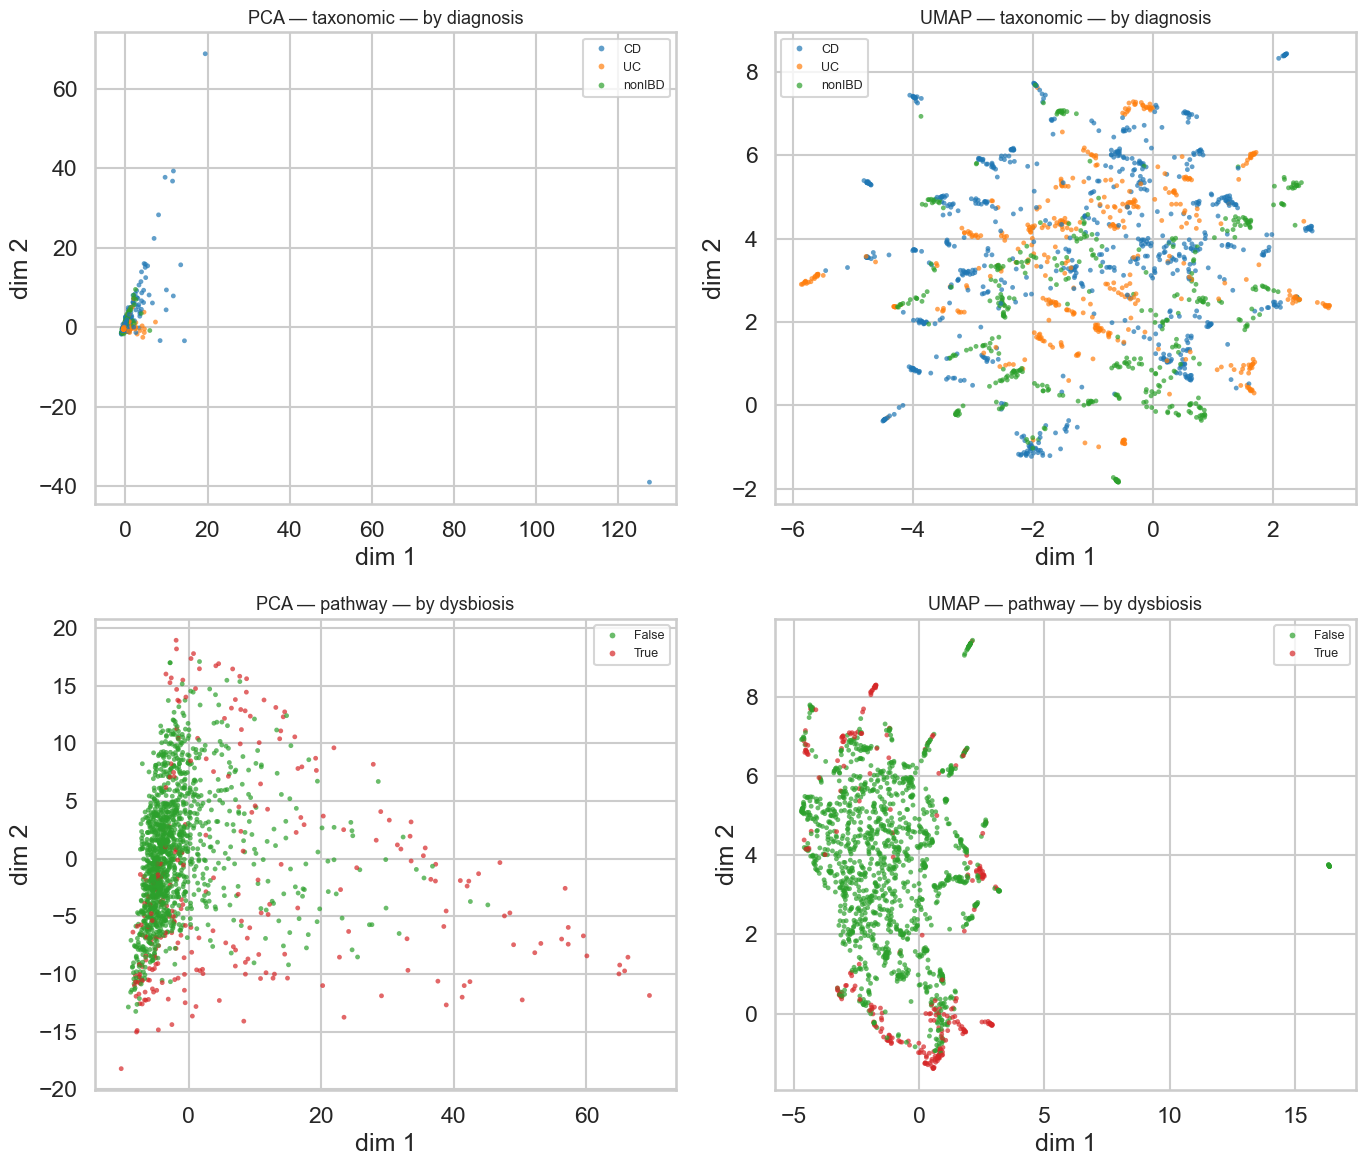

Saved explore_overview.png


In [12]:
def plot_embedding(ax, emb, color_series, title, palette=None):
    sns.scatterplot(
        x=emb[:, 0], y=emb[:, 1], hue=color_series, s=12, alpha=0.7,
        ax=ax, palette=palette, edgecolor="none",
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
    ax.legend(fontsize=9, markerscale=1.2, loc="best")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_embedding(axes[0, 0], pca_tax, labels["diagnosis"], "PCA — taxonomic — by diagnosis", palette="tab10")
plot_embedding(axes[0, 1], umap_tax, labels["diagnosis"], "UMAP — taxonomic — by diagnosis", palette="tab10")
plot_embedding(axes[1, 0], pca_path, labels["is_dysbiotic"].astype(str), "PCA — pathway — by dysbiosis",
               palette={"True": "#d62728", "False": "#2ca02c"})
plot_embedding(axes[1, 1], umap_path, labels["is_dysbiotic"].astype(str), "UMAP — pathway — by dysbiosis",
               palette={"True": "#d62728", "False": "#2ca02c"})

plt.tight_layout()
plt.savefig("explore_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved explore_overview.png")

## 10. Save processed artefacts

Cache the aligned matrices + labels as compressed parquet so the next notebooks don't have to re-parse the gzipped TSVs.

In [13]:
PROCESSED = Path("processed")
PROCESSED.mkdir(exist_ok=True)

labels.to_parquet(PROCESSED / "labels.parquet", index=False)
X_tax_aligned.to_parquet(PROCESSED / "X_tax_species.parquet")
X_path_aligned.to_parquet(PROCESSED / "X_pathway_community.parquet")

print("saved:")
for p in sorted(PROCESSED.iterdir()):
    print(f"  {p}  ({p.stat().st_size / 1024:.1f} KB)")

saved:
  processed/X_pathway_community.parquet  (4192.4 KB)
  processed/X_tax_species.parquet  (1290.6 KB)
  processed/labels.parquet  (44.9 KB)
  processed/split.json  (2.7 KB)
  processed/task_a_results.csv  (0.4 KB)


---
# Modelling: dysbiotic vs. non-dysbiotic classification

Goal: build a **comparison table** of methods on the same patient-level split, with the same metric.

| Method | Type |
|---|---|
| Elastic Net | classical, linear |
| PCA + Logistic Regression | classical, linear w/ feature reduction |
| Autoencoder + Logistic Regression | deep, non-linear representation |

Later notebooks will add VAE, contrastive encoder, and masked-feature autoencoder using the same split.

## 11. Patient-level train / val / test split

**Critical rule:** never put samples from the same `participant_id` in different splits. Each patient has many longitudinal samples; mixing them across train/test is the most common way to inflate microbiome ML scores.

In [14]:
import json
from sklearn.model_selection import train_test_split

SEED = 0

participants = (
    labels.groupby("participant_id")
    .agg(p_dys=("is_dysbiotic", "mean"),
         n_samples=("sample_id", "count"))
    .reset_index()
)
participants["any_dys"] = participants["p_dys"] > 0
print(f"participants: {len(participants)}  (any-dysbiotic: {participants['any_dys'].sum()})")

trainval_p, test_p = train_test_split(
    participants["participant_id"], test_size=0.20,
    stratify=participants["any_dys"], random_state=SEED,
)
trainval = participants[participants["participant_id"].isin(trainval_p)]
train_p, val_p = train_test_split(
    trainval["participant_id"], test_size=0.20 / 0.80,
    stratify=trainval["any_dys"], random_state=SEED,
)

split_map = {p: "train" for p in train_p}
split_map.update({p: "val"  for p in val_p})
split_map.update({p: "test" for p in test_p})
labels["split"] = labels["participant_id"].map(split_map)

print("\nparticipants per split:")
print(labels.drop_duplicates("participant_id")["split"].value_counts())
print("\nsamples per split:")
print(labels["split"].value_counts())
print("\nis_dysbiotic rate per split:")
print(labels.groupby("split")["is_dysbiotic"].mean().round(3))

with open("processed/split.json", "w") as f:
    json.dump({"seed": SEED, "split": split_map}, f, indent=2)
print("\nsaved processed/split.json")

participants: 130  (any-dysbiotic: 57)

participants per split:
split
train    78
val      26
test     26
Name: count, dtype: int64

samples per split:
split
train    977
val      343
test     275
Name: count, dtype: int64

is_dysbiotic rate per split:
split
test     0.240
train    0.163
val      0.137
Name: is_dysbiotic, dtype: float64

saved processed/split.json


## 12. Evaluation harness

Single function that takes a model + features and reports `AUROC`, `AUPRC`, and `F1` on val and test. Every method below uses this so the comparison is fair.

In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

y = labels["is_dysbiotic"].astype(int).values
split = labels["split"].values
idx_tr  = np.where(split == "train")[0]
idx_va  = np.where(split == "val")[0]
idx_te  = np.where(split == "test")[0]

print(f"train: {len(idx_tr):4d}   val: {len(idx_va):4d}   test: {len(idx_te):4d}")

def evaluate(name: str, X: np.ndarray, model, results: list):
    """Fit on train, evaluate on val and test. Append a row to `results`."""
    model.fit(X[idx_tr], y[idx_tr])
    if hasattr(model, "predict_proba"):
        prob_va = model.predict_proba(X[idx_va])[:, 1]
        prob_te = model.predict_proba(X[idx_te])[:, 1]
    else:
        prob_va = model.decision_function(X[idx_va])
        prob_te = model.decision_function(X[idx_te])
    pred_va = (prob_va >= 0.5).astype(int)
    pred_te = (prob_te >= 0.5).astype(int)
    row = {
        "method":     name,
        "val_auroc":  roc_auc_score(y[idx_va], prob_va),
        "val_auprc":  average_precision_score(y[idx_va], prob_va),
        "val_f1":     f1_score(y[idx_va], pred_va),
        "test_auroc": roc_auc_score(y[idx_te], prob_te),
        "test_auprc": average_precision_score(y[idx_te], prob_te),
        "test_f1":    f1_score(y[idx_te], pred_te),
    }
    results.append(row)
    print(
        f"{name:35s}  "
        f"val AUROC={row['val_auroc']:.3f} AUPRC={row['val_auprc']:.3f} F1={row['val_f1']:.3f}  |  "
        f"test AUROC={row['test_auroc']:.3f} AUPRC={row['test_auprc']:.3f} F1={row['test_f1']:.3f}"
    )

results = []

train:  977   val:  343   test:  275


## 13. Classical baseline 1 — Elastic Net

`LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5)` on the **arcsinh-standardized** features.

Standardizer is fit on `train` only — fitting it on the whole dataset would leak test statistics into training.

In [16]:
from sklearn.linear_model import LogisticRegression

def transform_train_only(X_df: pd.DataFrame) -> np.ndarray:
    Xa = np.arcsinh(X_df.values)
    sc = StandardScaler().fit(Xa[idx_tr])
    return sc.transform(Xa)

X_tax_s  = transform_train_only(X_tax_aligned)
X_path_s = transform_train_only(X_path_aligned)

def make_enet():
    return LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5, C=1.0,
        max_iter=5000, class_weight="balanced", random_state=SEED, n_jobs=-1,
    )

evaluate("ElasticNet (species)",  X_tax_s,  make_enet(), results)
evaluate("ElasticNet (pathways)", X_path_s, make_enet(), results)

/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


ElasticNet (species)                 val AUROC=0.777 AUPRC=0.397 F1=0.505  |  test AUROC=0.857 AUPRC=0.694 F1=0.662


/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


ElasticNet (pathways)                val AUROC=0.903 AUPRC=0.581 F1=0.608  |  test AUROC=0.940 AUPRC=0.866 F1=0.733


## 14. Classical baseline 2 — PCA + Logistic Regression

PCA fitted on **train only**, reduce to 32 dims, then standard logistic regression. This is the linear "deep-style" baseline mentioned in the thesis abstract.

In [17]:
def pca_embed(X: np.ndarray, n_components: int = 32) -> np.ndarray:
    pca = PCA(n_components=n_components, random_state=SEED).fit(X[idx_tr])
    return pca.transform(X)

Z_pca_tax  = pca_embed(X_tax_s,  32)
Z_pca_path = pca_embed(X_path_s, 32)

def make_lr():
    return LogisticRegression(
        max_iter=5000, class_weight="balanced", random_state=SEED, n_jobs=-1,
    )

evaluate("PCA32 + LR (species)",  Z_pca_tax,  make_lr(), results)
evaluate("PCA32 + LR (pathways)", Z_pca_path, make_lr(), results)

PCA32 + LR (species)                 val AUROC=0.849 AUPRC=0.605 F1=0.642  |  test AUROC=0.612 AUPRC=0.507 F1=0.490
PCA32 + LR (pathways)                val AUROC=0.882 AUPRC=0.710 F1=0.617  |  test AUROC=0.885 AUPRC=0.738 F1=0.654


/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 15. Deep baseline — Autoencoder + Logistic Regression

Simple bottleneck autoencoder in PyTorch:

`input → 256 → 64 → 32 (bottleneck) → 64 → 256 → input`

Trained **unsupervised** (MSE reconstruction) on `train` only. The 32-dim bottleneck embedding is then fed to a logistic regression — same classifier head as the PCA baseline so the comparison is purely "PCA vs. learned representation" with everything else held fixed.

This is the simplest deep baseline. VAE / contrastive / masked-feature variants will be separate notebooks using the same harness.

In [19]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")


class Autoencoder(nn.Module):
    def __init__(self, in_dim: int, bottleneck: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


def ae_embed(X: np.ndarray, bottleneck: int = 32, epochs: int = 200,
             batch_size: int = 64, lr: float = 1e-3) -> np.ndarray:
    X_tr = torch.tensor(X[idx_tr], dtype=torch.float32, device=DEVICE)
    X_va = torch.tensor(X[idx_va], dtype=torch.float32, device=DEVICE)
    X_all = torch.tensor(X, dtype=torch.float32, device=DEVICE)

    ds = TensorDataset(X_tr)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model = Autoencoder(X.shape[1], bottleneck).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val, best_state, patience, bad = float("inf"), None, 20, 0
    for ep in range(epochs):
        model.train()
        for (xb,) in dl:
            opt.zero_grad()
            xh, _ = model(xb)
            loss = loss_fn(xh, xb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            xh_va, _ = model(X_va)
            val_loss = loss_fn(xh_va, X_va).item()
        if val_loss < best_val - 1e-5:
            best_val, best_state, bad = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    print(f"  AE trained: best val MSE = {best_val:.4f}, epoch ~{ep - patience}")

    model.eval()
    with torch.no_grad():
        _, Z = model(X_all)
    return Z.detach().cpu().numpy()


print("training AE on species features...")
Z_ae_tax  = ae_embed(X_tax_s,  bottleneck=32, epochs=200)
print("training AE on pathway features...")
Z_ae_path = ae_embed(X_path_s, bottleneck=32, epochs=200)

evaluate("AE32 + LR (species)",  Z_ae_tax,  make_lr(), results)
evaluate("AE32 + LR (pathways)", Z_ae_path, make_lr(), results)

device: mps
training AE on species features...
  AE trained: best val MSE = 104.1300, epoch ~32
training AE on pathway features...
  AE trained: best val MSE = 5.8667, epoch ~139
AE32 + LR (species)                  val AUROC=0.699 AUPRC=0.428 F1=0.462  |  test AUROC=0.495 AUPRC=0.407 F1=0.349
AE32 + LR (pathways)                 val AUROC=0.839 AUPRC=0.455 F1=0.563  |  test AUROC=0.809 AUPRC=0.655 F1=0.581


/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/arijus/miniconda3/envs/masters/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 16. Results table & comparison plot

In [20]:
res = pd.DataFrame(results).set_index("method").round(3)
res.to_csv("processed/task_a_results.csv")
res

,val_auroc,val_auprc,val_f1,test_auroc,test_auprc,test_f1
method,,,,,,
ElasticNet (species),0.777,0.397,0.505,0.857,0.694,0.662
ElasticNet (pathways),0.903,0.581,0.608,0.940,0.866,0.733
PCA32 + LR (species),0.849,0.605,0.642,0.612,0.507,0.490
PCA32 + LR (pathways),0.882,0.710,0.617,0.885,0.738,0.654
AE32 + LR (species),0.699,0.428,0.462,0.495,0.407,0.349
AE32 + LR (pathways),0.839,0.455,0.563,0.809,0.655,0.581
AE32 + LR (species),0.699,0.428,0.462,0.495,0.407,0.349
AE32 + LR (pathways),0.839,0.455,0.563,0.809,0.655,0.581


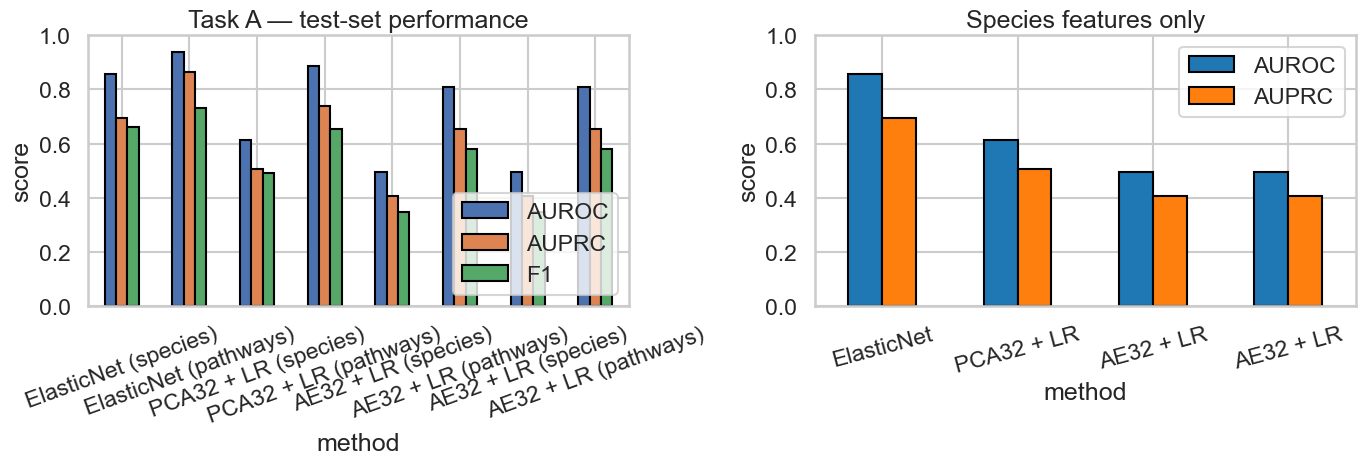

saved task_a_results.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_plot = res[["test_auroc", "test_auprc", "test_f1"]].copy()
metrics_plot.columns = ["AUROC", "AUPRC", "F1"]
metrics_plot.plot(kind="bar", ax=axes[0], rot=20, edgecolor="black")
axes[0].set_title("Task A — test-set performance"); axes[0].set_ylim(0, 1)
axes[0].set_ylabel("score"); axes[0].legend(loc="lower right")

species_only = res[res.index.str.contains(r"\(species\)")][["test_auroc", "test_auprc"]]
species_only.index = species_only.index.str.replace(r" \(species\)", "", regex=True)
species_only.plot(kind="bar", ax=axes[1], rot=15, edgecolor="black",
                  color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("Species features only"); axes[1].set_ylim(0, 1)
axes[1].set_ylabel("score"); axes[1].legend(["AUROC", "AUPRC"])

plt.tight_layout()
plt.savefig("task_a_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved task_a_results.png")

## What's next

This notebook is **Task A first pass**. From here:

- [ ] Scale up input features: `ecs_relab.tsv.gz` (~3,000 community-level features) and eventually `genefamilies_relab.tsv.gz`.
- [ ] Replace the autoencoder with **VAE**, **contrastive encoder**, **masked-feature autoencoder** — same harness, just swap `ae_embed`.
- [ ] Add **CD vs. UC vs. nonIBD** as a second classification task (the current target is dysbiosis).
- [ ] Move shared code (`evaluate`, `transform_train_only`, `Autoencoder`) into a `src/` package so notebooks 02, 03, 04 can `from src import …`.
- [ ] **Task B**: protein prioritization. Will need MetaWIBELE outputs + ESM-2 sequence embeddings.
- [ ] **Task C**: cross-cohort generalization. Train on HMP2, test on PRISM (or whichever cohort the supervisor specifies).

Reproduce: `conda activate masters && jupyter lab` and run all cells.